# Bank Loan Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


In [7]:
df = pd.read_excel("financial_loan_data_excel (1).xlsx")

In [8]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [9]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### meta data

In [10]:
print("No of rows: ",df.shape[0])

No of rows:  38576


In [11]:
print("No of columns: ",df.shape[1])

No of columns:  24


In [12]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

### data types

In [13]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [14]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


## kpis

### total loan aplications

In [15]:
total_loan_applications = df['id'].count()
print("Total Loan Applications: ",total_loan_applications)

Total Loan Applications:  38576


In [16]:
print("Total Loan Applications: ",df['id'].count())

Total Loan Applications:  38576


In [17]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_loan_applications = mtd_data['id'].count()

print(f"MTD Loan Applicatons( for {latest_issue_date.strftime('%B %Y')}):{mtd_loan_applications}")



MTD Loan Applicatons( for December 2021):4314


### Total Funded Amount

In [18]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_millions = total_funded_amount/1000000
print("Total Funded Amount: ${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount: $435.76M


### MTD Total Amount Received

In [19]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month ==latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions = mtd_total_funded_amount/1000000

print("MTD Total Funded Amount: ",mtd_total_funded_amount_millions)


MTD Total Funded Amount:  53.981425


### Average Interest rate

In [20]:
aveage_interest_rate = df['int_rate'].mean()*100
print("Avg Int Rate: {:.2f}%".format(aveage_interest_rate))

Avg Int Rate: 12.05%


### Average Dept to Income ration

In [21]:
avarage_dti = df['dti'].mean()*100
print("Average Dept to Income Ratio: {:.2f}%".format(avarage_dti))

Average Dept to Income Ratio: 13.33%


### Good Loan Meetrics

In [22]:

good_loans = df[df['loan_status'].isin(["Fully Paid", "Current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1_000_000
good_loan_received_millions = good_loan_received / 1_000_000

good_loan_percentage = (good_loan_applications / total_loan_applications) * 100

print(f"Good Loan Applications: {good_loan_applications}")
print(f"Good Loan Funded Amount: ${good_loan_funded_amount_millions:.2f}M")
print(f"Good Loan Total Received: ${good_loan_received_millions:.2f}M")
print(f"Good Loan Percentage: {good_loan_percentage:.2f}%")

Good Loan Applications: 33243
Good Loan Funded Amount: $370.22M
Good Loan Total Received: $435.79M
Good Loan Percentage: 86.18%


### Bad loan matrix

In [23]:
bad_loans = df[df['loan_status'].isin(["Charged Off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = good_loan_funded_amount / 1_000_000
bad_loan_received_millions = good_loan_received / 1_000_000

bad_loan_percentage = (bad_loan_applications / total_loan_applications) * 100

print(f"Bad Loan Applications: {bad_loan_applications}")
print(f"Bad Loan Funded Amount: ${bad_loan_funded_amount_millions:.2f}M")
print(f"Bad Loan Total Received: ${bad_loan_received_millions:.2f}M")
print(f"Bad Loan Percentage: {bad_loan_percentage:.2f}%")

Bad Loan Applications: 5333
Bad Loan Funded Amount: $370.22M
Bad Loan Total Received: $435.79M
Bad Loan Percentage: 13.82%


### Monthly Trends by Date for Total AmountFunded

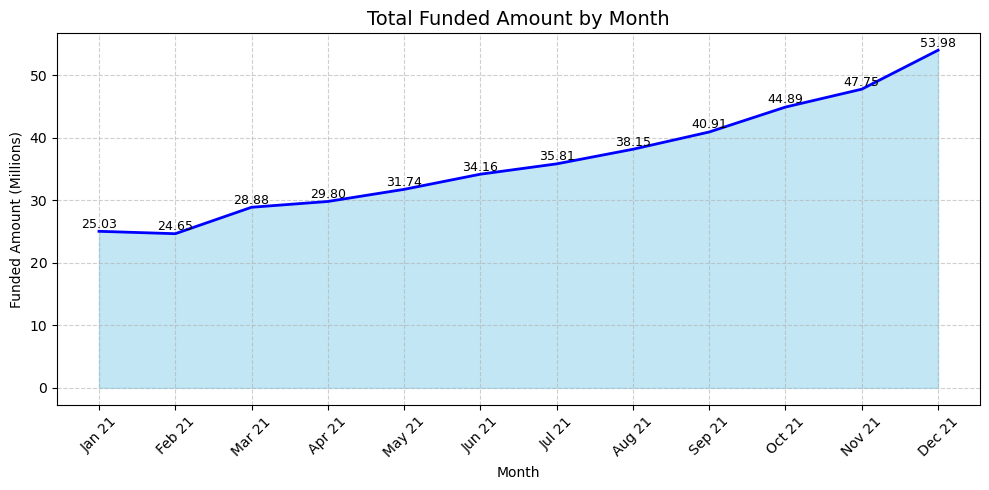

In [24]:
monthly_funded = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1000000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',
    alpha=0.5
)

plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',
    linewidth=2
)

for i, row in monthly_funded.iterrows():
    plt.text(
        i,
        row['loan_amount_millions'] + 0.1,
        f"{row['loan_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (Millions)')

plt.xticks(
    ticks=range(len(monthly_funded)),
    labels=monthly_funded['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Amount Received

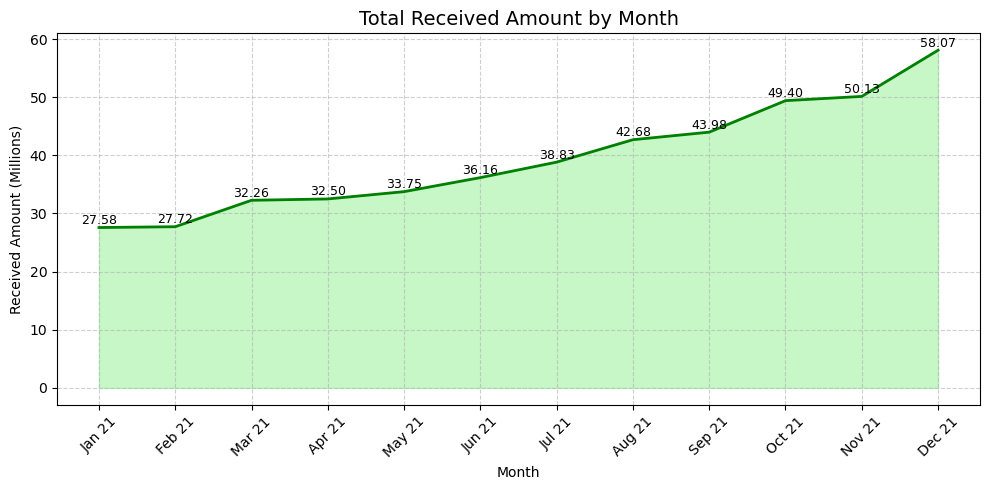

In [25]:
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1000000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)

plt.plot(
    monthly_received['month_name'],
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (Millions)')

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Monthly Trends by Issue Date for Total Loan Applications

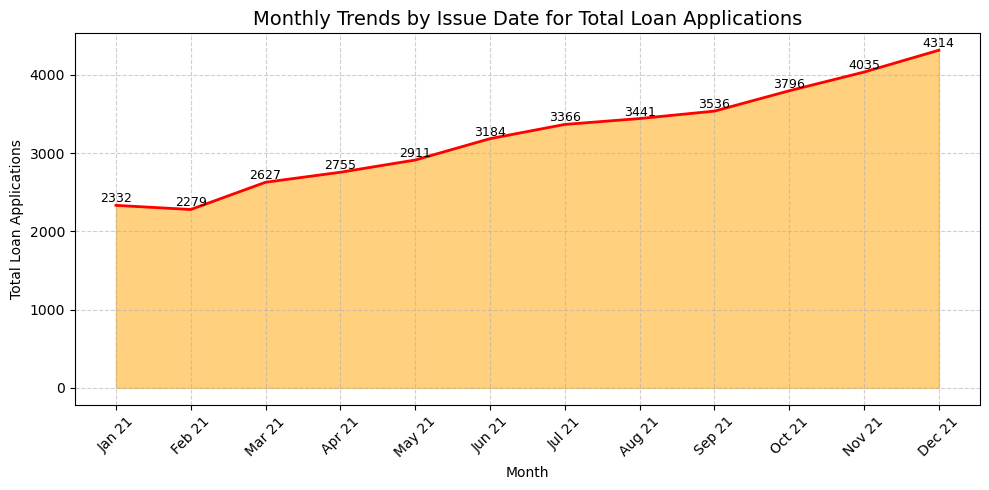

In [26]:
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='total_loan_applications')
)

plt.figure(figsize=(10,5))

plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='orange',
    alpha=0.5
)

plt.plot(
    monthly_applications['month_name'],
    monthly_applications['total_loan_applications'],
    color='red',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['total_loan_applications'] + 0.5,
        f"{row['total_loan_applications']}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Monthly Trends by Issue Date for Total Loan Applications', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Loan Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Regional Analysis by State for Total Funded Amount

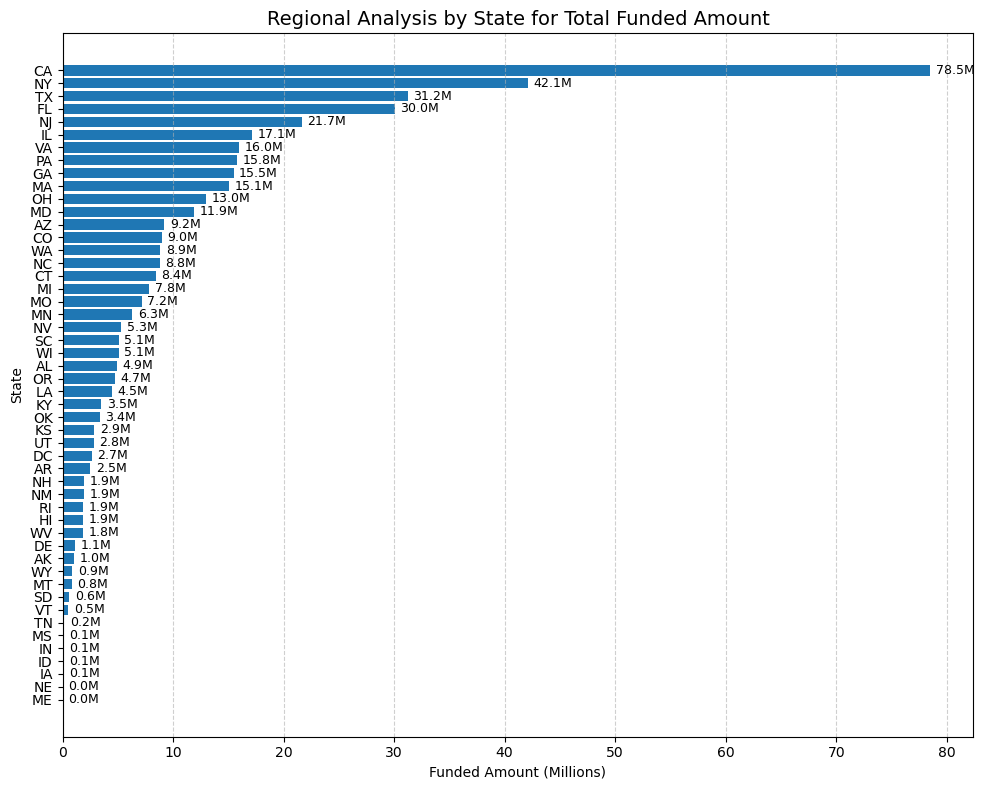

In [27]:
state_funded = (
    df.groupby('address_state')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=True)
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    state_funded['address_state'],
    state_funded['funded_amount_millions']
)

for i, value in enumerate(state_funded['funded_amount_millions']):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}M",
        va='center',
        fontsize=9
    )

plt.title('Regional Analysis by State for Total Funded Amount', fontsize=14)
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('State')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

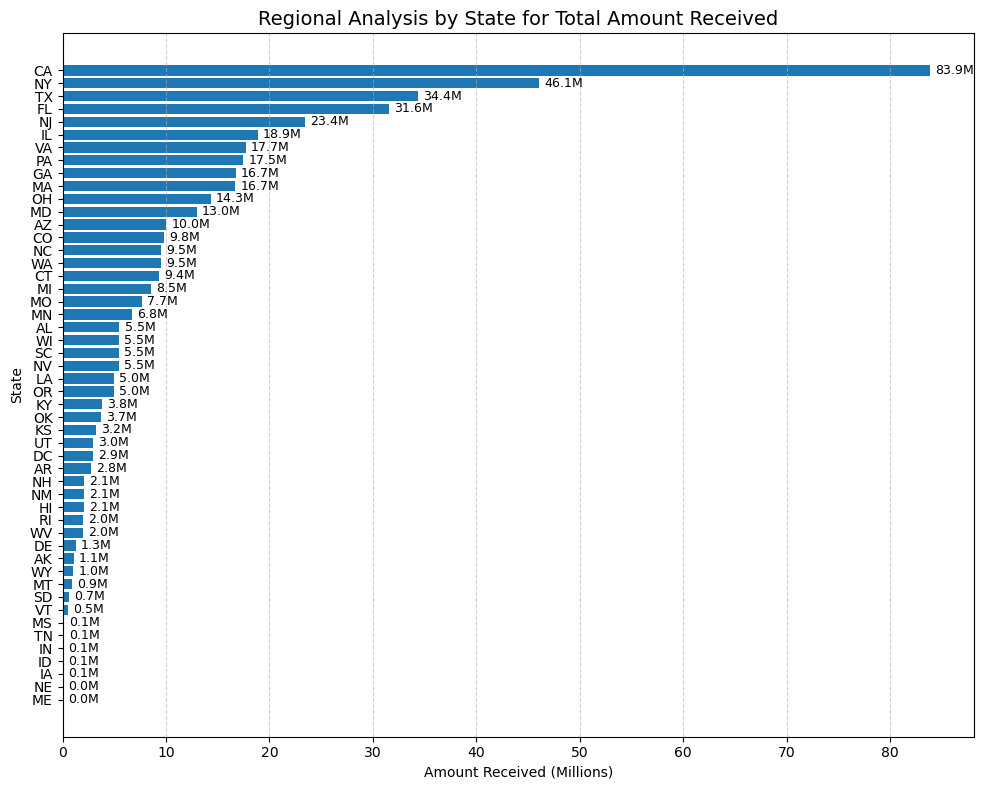

In [28]:
state_received = (
    df.groupby('address_state')['total_payment']
      .sum()
      .div(1000000)
      .sort_values(ascending=True)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    state_received['address_state'],
    state_received['received_amount_millions']
)

for i, value in enumerate(state_received['received_amount_millions']):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}M",
        va='center',
        fontsize=9
    )

plt.title('Regional Analysis by State for Total Amount Received', fontsize=14)
plt.xlabel('Amount Received (Millions)')
plt.ylabel('State')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

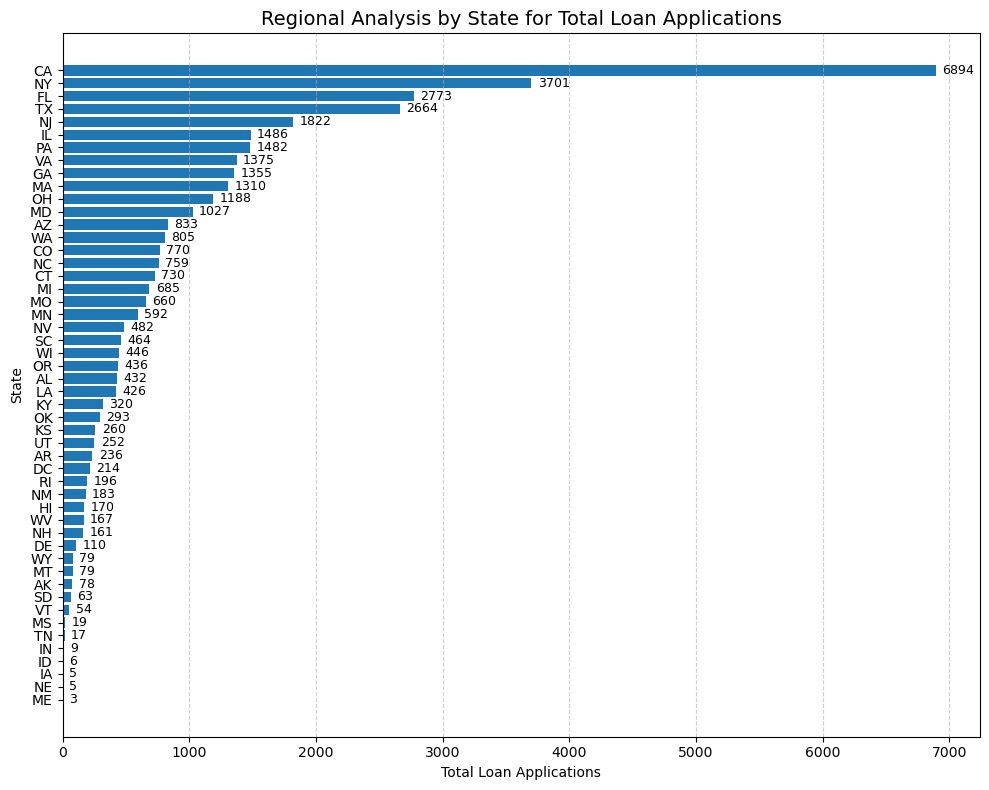

In [29]:
state_applications = (
    df.groupby('address_state')['id']
      .count()
      .sort_values(ascending=True)
      .reset_index(name='total_loan_applications')
)

plt.figure(figsize=(10,8))

bars = plt.barh(
    state_applications['address_state'],
    state_applications['total_loan_applications']
)

for i, value in enumerate(state_applications['total_loan_applications']):
    plt.text(
        value + 50,
        i,
        f"{value}",
        va='center',
        fontsize=9
    )

plt.title('Regional Analysis by State for Total Loan Applications', fontsize=14)
plt.xlabel('Total Loan Applications')
plt.ylabel('State')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize = (5,5))
plt.pie(
    term_funding_millions,
    labels = term_funding_millions.index,
    autopct = lambda p: f"{p:.1f}%\n${p*sum(term_funding_milllions)/100:.1f}M",
    stetangle = 90,
    wedgeprops = {'width': 0.4}
)
plt.gca().term_funding_millions = (
    df.groupby('term')['loan_amount']
      .sum() / 1000000
)

plt.figure(figsize=(5,5))

plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p * term_funding_millions.sum() / 100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.gca().add_artist(
    plt.Circle((0,0), 0.70, color='white')
)

plt.title("Total Funded Amount by Term (in Millions)")

plt.show()add_artist(plt.Circle((0,0), 0.70, color = 'white'))
plt.title("Total Funded Amount by Term (in Millions)")
plt.show()

SyntaxError: invalid syntax (3569648792.py, line 32)

In [ ]:
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p * term_funding_millions.sum() / 100:.1f}M",
    startangle=90,
    wedgeprops={'width':0.4}
)

plt.gca().add_artist(
    plt.Circle((0,0), 0.70, color='white')
)

plt.title("Total Funded Amount by Term (in Millions)")

plt.show()

### Employee length by total funded amont

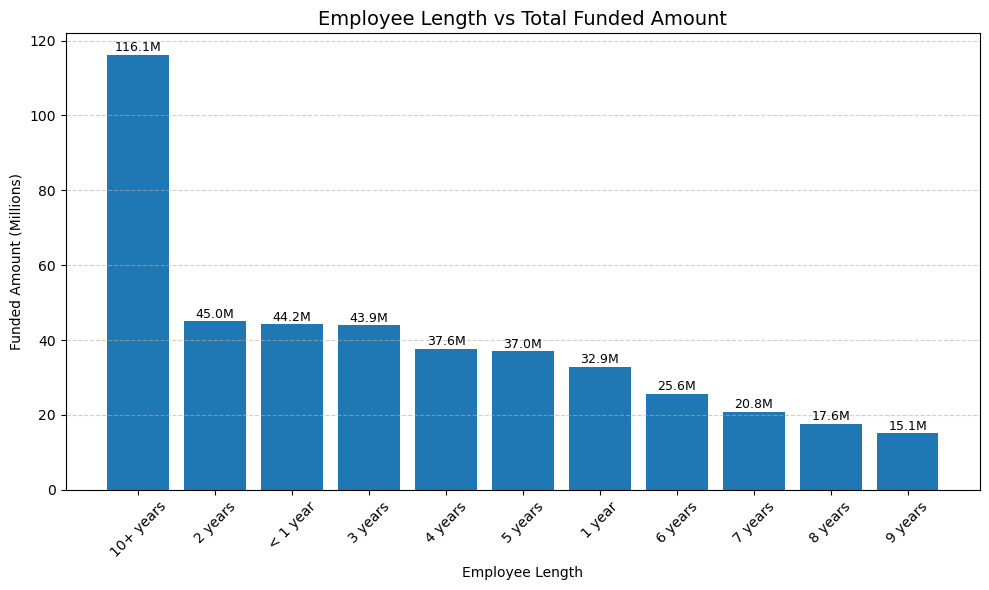

In [32]:
emp_length_funded = (
    df.groupby('emp_length')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=False)
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    emp_length_funded['emp_length'],
    emp_length_funded['funded_amount_millions']
)

for i, value in enumerate(emp_length_funded['funded_amount_millions']):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}M",
        ha='center',
        fontsize=9
    )

plt.title('Employee Length vs Total Funded Amount', fontsize=14)
plt.xlabel('Employee Length')
plt.ylabel('Funded Amount (Millions)')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Loan purpose by Total Funded amount

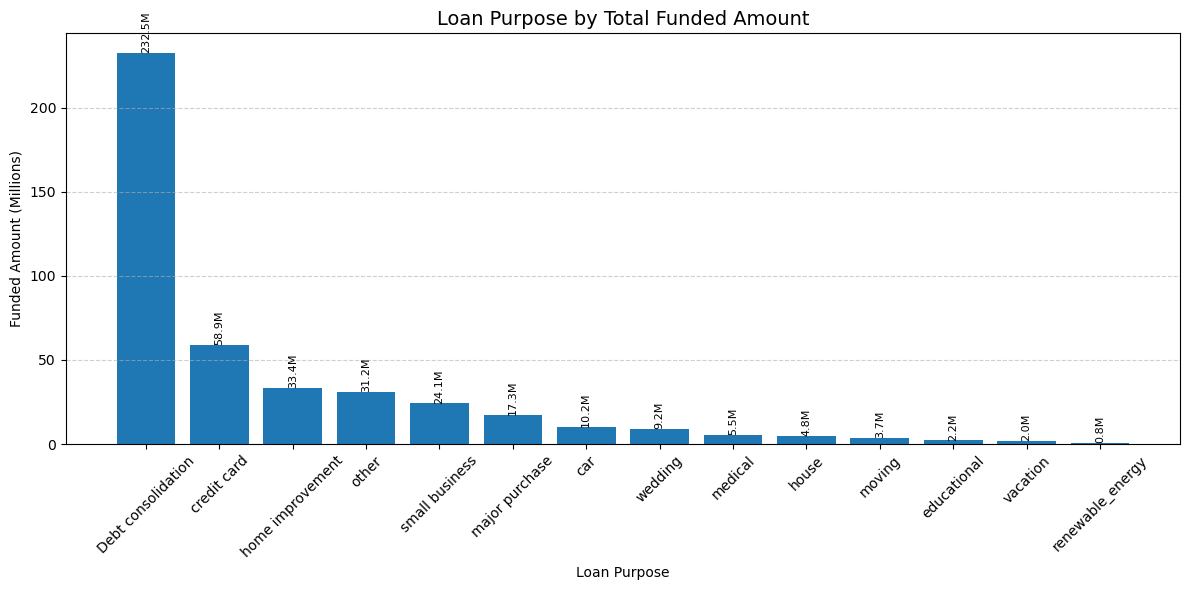

In [33]:
purpose_funded = (
    df.groupby('purpose')['loan_amount']
      .sum()
      .div(1000000)
      .sort_values(ascending=False)
      .reset_index(name='funded_amount_millions')
)

plt.figure(figsize=(12,6))

bars = plt.bar(
    purpose_funded['purpose'],
    purpose_funded['funded_amount_millions']
)

for i, value in enumerate(purpose_funded['funded_amount_millions']):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}M",
        ha='center',
        fontsize=8,
        rotation=90
    )

plt.title('Loan Purpose by Total Funded Amount', fontsize=14)
plt.xlabel('Loan Purpose')
plt.ylabel('Funded Amount (Millions)')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Home ownership by Total Funded amount

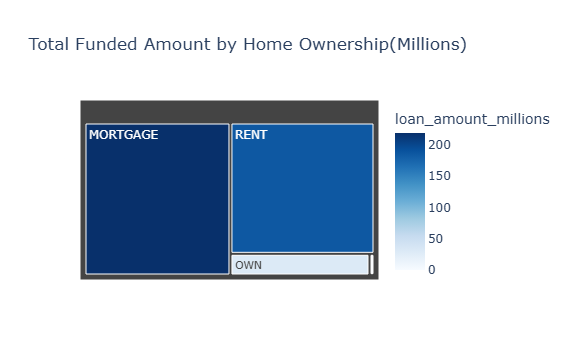

In [35]:
home_funding = df.groupby('home_ownership')['loan_amount'].sum().reset_index()
home_funding['loan_amount_millions'] = home_funding['loan_amount']/1_000_000

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership(Millions)',
)
fig.show()

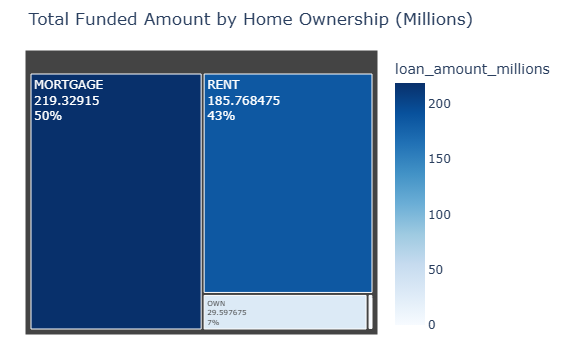

In [36]:
home_funding = (
    df.groupby('home_ownership')['loan_amount']
      .sum()
      .reset_index()
)

home_funding['loan_amount_millions'] = (
    home_funding['loan_amount'] / 1_000_000
)

fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (Millions)'
)

fig.update_traces(
    textinfo='label+value+percent entry'
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()